In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import matplotlib.patches as mpatches
from shapely.geometry import MultiPoint
from sklearn.neighbors import NearestNeighbors

# Set global display format to show up to 6 decimal places
pd.options.display.float_format = '{:.6f}'.format

# 1. Load and Visualize Data

In [2]:
SVI_csv_path = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Correct_SVI.csv"
df = pd.read_csv(SVI_csv_path)
df

,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction
0,20161115_133906,2016,11,15.000000,13.000000,-1.317033,36.791557,NaN,Faith/,True,"[0.4858177900314331, 0.3025636374950409]","[[28.5167236328125, 1253.941650390625, 776.544...",2,yes,Y,N
1,20161115_131903,2016,11,15.000000,13.000000,-1.319186,36.793816,NaN,Faith/,True,"[0.39657795429229736, 0.26016801595687866]","[[0.0, 1408.639892578125, 1536.0, 2483.7131347...",2,yes,Y,Y
2,01d56d3da7a7276ef16b2c8e2196246655518296d0,2015,8,22.000000,13.000000,-1.312889,36.867031,NaN,Faith/,True,"[0.34240347146987915, 0.3375213146209717]","[[337.49151611328125, 889.6815185546875, 2056....",2,yes,Y,N
3,20161115_131056,2016,11,15.000000,13.000000,-1.319284,36.794905,NaN,Faith/,True,[0.29595947265625],"[[1217.840576171875, 2147.228515625, 1536.0, 2...",1,yes,Y,N
4,20161115_140900,2016,11,15.000000,14.000000,-1.316989,36.789524,NaN,Faith/,True,[0.5429480075836182],"[[497.2809753417969, 863.2463989257812, 1345.1...",1,yes,Y,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4077,IMG_7819,2023,2,9.000000,12.000000,-1.312181,36.870267,NaN,ZWL/,True,"[0.7798725366592407, 0.3829556405544281]","[[2542.110595703125, 1953.2369384765625, 4013....",2,yes,Y,N
4078,IMG_20230211_122605,2023,2,11.000000,12.000000,NaN,NaN,NaN,ZWL/,True,[0.46833276748657227],"[[1749.275634765625, 1453.630859375, 3514.6911...",1,yes,Y,Y
4079,IMG_6440,2023,2,3.000000,12.000000,-1.315433,36.790297,NaN,ZWL/,True,[0.4961458146572113],"[[2177.84375, 844.6050415039062, 3318.18994140...",1,yes,Y,N
4080,IMG_6468,2023,2,3.000000,13.000000,-1.306761,36.783131,NaN,ZWL/,True,"[0.41568389534950256, 0.2513587474822998]","[[2769.41552734375, 2133.168701171875, 4032.0,...",2,yes,Y,N


In [17]:
df = df[~df['img_dir'].isin(['Faith/', 'ZWL/'])]
df

,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction,geometry
73,1Xyfr0j4E3Gx6_Coadexow_180,2018,2,NaN,NaN,-1.282457,36.751317,1Xyfr0j4E3Gx6_Coadexow,Google/1/X/,True,[0.4008658230304718],"[[298.3153076171875, 184.95751953125, 400.0, 2...",1,yes,Y,Y,POINT (36.75131748573157 -1.282456526709289)
74,nTRlyH7aG8CmTfOI1_akgw_0,2018,3,NaN,NaN,-1.279155,36.719541,nTRlyH7aG8CmTfOI1_akgw,Google/n/T/,True,"[0.5433366894721985, 0.3535045087337494]","[[50.18629455566406, 221.9884033203125, 188.91...",2,yes,Y,N,POINT (36.71954091443794 -1.279154709947858)
75,uc2yRcVOf6bCSyBKfnm0Sw_90,2018,2,NaN,NaN,-1.283062,36.751316,uc2yRcVOf6bCSyBKfnm0Sw,Google/u/c/,True,"[0.3149861693382263, 0.2503598630428314]","[[0.0, 248.11912536621094, 191.11526489257812,...",2,yes,Y,Y,POINT (36.75131567687964 -1.283062375352888)
76,y_-_BCz3RPfZPFkLoqlA7Q_0,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.3682653307914734],"[[185.56979370117188, 191.65072631835938, 309....",1,yes,Y,Y,POINT (36.74569396310746 -1.285055872853599)
77,y_-_BCz3RPfZPFkLoqlA7Q_90,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.27535533905029297],"[[71.40460968017578, 221.17556762695312, 324.6...",1,yes,Y,Y,POINT (36.74569396310746 -1.285055872853599)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3965,K2bDOcQT-fC73J3sTszcJw_0,2021,8,NaN,NaN,-1.314196,36.889760,K2bDOcQT-fC73J3sTszcJw,Google/K/2/,True,[0.5377181172370911],"[[322.23724365234375, 0.0, 399.8905944824219, ...",1,yes,Y,Y,POINT (36.88975982215521 -1.314195839051848)
3966,A2MMbVUET-qhK8hNcteVBw_180,2018,2,NaN,NaN,-1.276726,36.919951,A2MMbVUET-qhK8hNcteVBw,Google/A/2/,True,[0.8420240879058838],"[[2.8917694091796875, 153.89686584472656, 383....",1,yes,Y,N,POINT (36.91995104207209 -1.276726396335839)
3967,zVDYat_guuNnsZ9DemVKwA_180,2018,2,NaN,NaN,-1.276957,36.919431,zVDYat_guuNnsZ9DemVKwA,Google/z/V/,True,[0.6924970149993896],"[[0.0, 183.14369201660156, 185.0641632080078, ...",1,yes,Y,Y,POINT (36.91943054257073 -1.276956925349207)
3968,u_Zx9slVChF217zkkuGJnw_0,2021,8,NaN,NaN,-1.313337,36.872663,u_Zx9slVChF217zkkuGJnw,Google/u/_/,True,[0.40619784593582153],"[[126.26983642578125, 238.47946166992188, 328....",1,yes,Y,N,POINT (36.8726631393441 -1.313337493233717)


In [18]:
# Ensure your df has 'lat' and 'lon' columns
df['geometry'] = df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

# Convert to a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
gdf

/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_30338/3193083130.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['geometry'] = df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)


,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction,geometry
73,1Xyfr0j4E3Gx6_Coadexow_180,2018,2,NaN,NaN,-1.282457,36.751317,1Xyfr0j4E3Gx6_Coadexow,Google/1/X/,True,[0.4008658230304718],"[[298.3153076171875, 184.95751953125, 400.0, 2...",1,yes,Y,Y,POINT (36.75132 -1.28246)
74,nTRlyH7aG8CmTfOI1_akgw_0,2018,3,NaN,NaN,-1.279155,36.719541,nTRlyH7aG8CmTfOI1_akgw,Google/n/T/,True,"[0.5433366894721985, 0.3535045087337494]","[[50.18629455566406, 221.9884033203125, 188.91...",2,yes,Y,N,POINT (36.71954 -1.27915)
75,uc2yRcVOf6bCSyBKfnm0Sw_90,2018,2,NaN,NaN,-1.283062,36.751316,uc2yRcVOf6bCSyBKfnm0Sw,Google/u/c/,True,"[0.3149861693382263, 0.2503598630428314]","[[0.0, 248.11912536621094, 191.11526489257812,...",2,yes,Y,Y,POINT (36.75132 -1.28306)
76,y_-_BCz3RPfZPFkLoqlA7Q_0,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.3682653307914734],"[[185.56979370117188, 191.65072631835938, 309....",1,yes,Y,Y,POINT (36.74569 -1.28506)
77,y_-_BCz3RPfZPFkLoqlA7Q_90,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.27535533905029297],"[[71.40460968017578, 221.17556762695312, 324.6...",1,yes,Y,Y,POINT (36.74569 -1.28506)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3965,K2bDOcQT-fC73J3sTszcJw_0,2021,8,NaN,NaN,-1.314196,36.889760,K2bDOcQT-fC73J3sTszcJw,Google/K/2/,True,[0.5377181172370911],"[[322.23724365234375, 0.0, 399.8905944824219, ...",1,yes,Y,Y,POINT (36.88976 -1.31420)
3966,A2MMbVUET-qhK8hNcteVBw_180,2018,2,NaN,NaN,-1.276726,36.919951,A2MMbVUET-qhK8hNcteVBw,Google/A/2/,True,[0.8420240879058838],"[[2.8917694091796875, 153.89686584472656, 383....",1,yes,Y,N,POINT (36.91995 -1.27673)
3967,zVDYat_guuNnsZ9DemVKwA_180,2018,2,NaN,NaN,-1.276957,36.919431,zVDYat_guuNnsZ9DemVKwA,Google/z/V/,True,[0.6924970149993896],"[[0.0, 183.14369201660156, 185.0641632080078, ...",1,yes,Y,Y,POINT (36.91943 -1.27696)
3968,u_Zx9slVChF217zkkuGJnw_0,2021,8,NaN,NaN,-1.313337,36.872663,u_Zx9slVChF217zkkuGJnw,Google/u/_/,True,[0.40619784593582153],"[[126.26983642578125, 238.47946166992188, 328....",1,yes,Y,N,POINT (36.87266 -1.31334)


In [30]:
# Load boundary shapefile
# boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/QGIS/Mukuru_BD.shp")
boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/QGIS/Kibera.shp")
# boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Shp/NariobiShp/Shp_from_Constituency/Nairobi_shp_C.shp")

# Ensure CRS match (convert if necessary)
gdf = gdf.to_crs(boundary.crs)

# Clip points inside the boundary
clipped_gdf = gpd.clip(gdf, boundary)

# Display result
clipped_gdf

# 1个框外 + 35没有坐标
# Original count: 4082
# Clipped count: 4046
# Removed count: 36
# Cliped within Nairobi count: 3385

,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction,geometry
186,-y5qL_P07u3ZZEfYmyoUvA_90,2021,7,NaN,NaN,-1.313860,36.781790,-y5qL_P07u3ZZEfYmyoUvA,Google/-/y/,True,[0.3565656542778015],"[[269.89776611328125, 245.382568359375, 399.24...",1,yes,Y,N,POINT (36.78179 -1.31386)
1547,ljLTC2fLqypx-0MKgrmPOA_270,2021,7,NaN,NaN,-1.313584,36.780332,ljLTC2fLqypx-0MKgrmPOA,Google/l/j/,True,"[0.4094972610473633, 0.3820793926715851]","[[198.3302459716797, 193.4246063232422, 252.48...",2,yes,Y,N,POINT (36.78033 -1.31358)
1108,xpOQCJ3amf_H13t27EzoeA_180,2021,7,NaN,NaN,-1.313528,36.780258,xpOQCJ3amf_H13t27EzoeA,Google/x/p/,True,[0.27658528089523315],"[[87.5762939453125, 200.91690063476562, 220.98...",1,yes,Y,N,POINT (36.78026 -1.31353)
166,KmpM3DAv4-PQI4nJlm0WMw_90,2021,7,NaN,NaN,-1.311757,36.774924,KmpM3DAv4-PQI4nJlm0WMw,Google/K/m/,True,[0.31415215134620667],"[[132.40505981445312, 214.43325805664062, 200....",1,yes,Y,N,POINT (36.77492 -1.31176)
487,HGhR-RreMROMH9Re1HtmQw_270,2021,7,NaN,NaN,-1.311586,36.777014,HGhR-RreMROMH9Re1HtmQw,Google/H/G/,True,[0.30344483256340027],"[[2.1403121948242188, 153.0401611328125, 86.35...",1,yes,Y,N,POINT (36.77701 -1.31159)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1382,8Xw68ZSwpdivrLRRjkOokA_180,2018,3,NaN,NaN,-1.304041,36.800910,8Xw68ZSwpdivrLRRjkOokA,Google/8/X/,True,[0.4353753626346588],"[[3.5274124145507812, 209.21096801757812, 180....",1,yes,Y,N,POINT (36.80091 -1.30404)
2625,MWWM3LxXYmVwa-BvsBBMfA_90,2021,7,NaN,NaN,-1.302247,36.788301,MWWM3LxXYmVwa-BvsBBMfA,Google/M/W/,True,"[0.5783674716949463, 0.3852565288543701, 0.308...","[[166.93585205078125, 158.0511474609375, 331.9...",3,yes,Y,N,POINT (36.78830 -1.30225)
254,K9rJxQGSZ7MIwCZ6KUC1bA_90,2018,1,NaN,NaN,-1.300135,36.787494,K9rJxQGSZ7MIwCZ6KUC1bA,Google/K/9/,True,"[0.7136363387107849, 0.3796733021736145]","[[2.4740982055664062, 223.7992706298828, 123.6...",2,yes,Y,N,POINT (36.78749 -1.30013)
2357,POtAk_FTwY4WAU7lk7ST1w_270,2018,3,NaN,NaN,-1.298604,36.812973,POtAk_FTwY4WAU7lk7ST1w,Google/P/O/,True,[0.2511194050312042],"[[1.6712379455566406, 161.25180053710938, 144....",1,yes,Y,Y,POINT (36.81297 -1.29860)


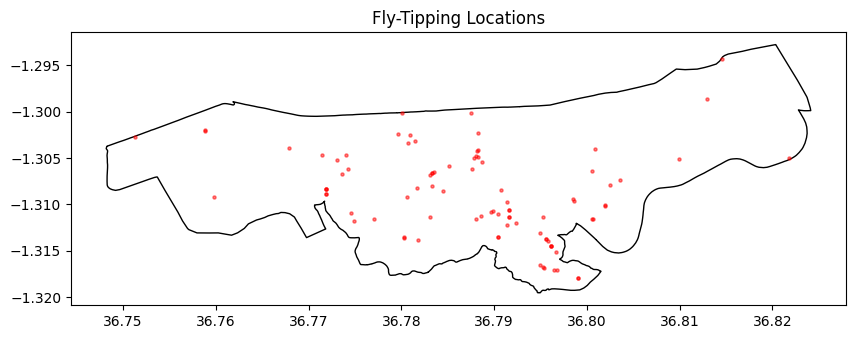

In [31]:
# Plot the points
fig, ax = plt.subplots(figsize=(10, 8))
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
clipped_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.5)
plt.title("Fly-Tipping Locations")
plt.show()


In [32]:
removed_gdf = gdf[~gdf.index.isin(clipped_gdf.index)]
removed_gdf

,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction,geometry
73,1Xyfr0j4E3Gx6_Coadexow_180,2018,2,NaN,NaN,-1.282457,36.751317,1Xyfr0j4E3Gx6_Coadexow,Google/1/X/,True,[0.4008658230304718],"[[298.3153076171875, 184.95751953125, 400.0, 2...",1,yes,Y,Y,POINT (36.75132 -1.28246)
74,nTRlyH7aG8CmTfOI1_akgw_0,2018,3,NaN,NaN,-1.279155,36.719541,nTRlyH7aG8CmTfOI1_akgw,Google/n/T/,True,"[0.5433366894721985, 0.3535045087337494]","[[50.18629455566406, 221.9884033203125, 188.91...",2,yes,Y,N,POINT (36.71954 -1.27915)
75,uc2yRcVOf6bCSyBKfnm0Sw_90,2018,2,NaN,NaN,-1.283062,36.751316,uc2yRcVOf6bCSyBKfnm0Sw,Google/u/c/,True,"[0.3149861693382263, 0.2503598630428314]","[[0.0, 248.11912536621094, 191.11526489257812,...",2,yes,Y,Y,POINT (36.75132 -1.28306)
76,y_-_BCz3RPfZPFkLoqlA7Q_0,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.3682653307914734],"[[185.56979370117188, 191.65072631835938, 309....",1,yes,Y,Y,POINT (36.74569 -1.28506)
77,y_-_BCz3RPfZPFkLoqlA7Q_90,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.27535533905029297],"[[71.40460968017578, 221.17556762695312, 324.6...",1,yes,Y,Y,POINT (36.74569 -1.28506)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3965,K2bDOcQT-fC73J3sTszcJw_0,2021,8,NaN,NaN,-1.314196,36.889760,K2bDOcQT-fC73J3sTszcJw,Google/K/2/,True,[0.5377181172370911],"[[322.23724365234375, 0.0, 399.8905944824219, ...",1,yes,Y,Y,POINT (36.88976 -1.31420)
3966,A2MMbVUET-qhK8hNcteVBw_180,2018,2,NaN,NaN,-1.276726,36.919951,A2MMbVUET-qhK8hNcteVBw,Google/A/2/,True,[0.8420240879058838],"[[2.8917694091796875, 153.89686584472656, 383....",1,yes,Y,N,POINT (36.91995 -1.27673)
3967,zVDYat_guuNnsZ9DemVKwA_180,2018,2,NaN,NaN,-1.276957,36.919431,zVDYat_guuNnsZ9DemVKwA,Google/z/V/,True,[0.6924970149993896],"[[0.0, 183.14369201660156, 185.0641632080078, ...",1,yes,Y,Y,POINT (36.91943 -1.27696)
3968,u_Zx9slVChF217zkkuGJnw_0,2021,8,NaN,NaN,-1.313337,36.872663,u_Zx9slVChF217zkkuGJnw,Google/u/_/,True,[0.40619784593582153],"[[126.26983642578125, 238.47946166992188, 328....",1,yes,Y,N,POINT (36.87266 -1.31334)


# 2. Kernel Density Estimation (KDE)
KDE provides a heatmap showing density variations, helping identify hotspots.


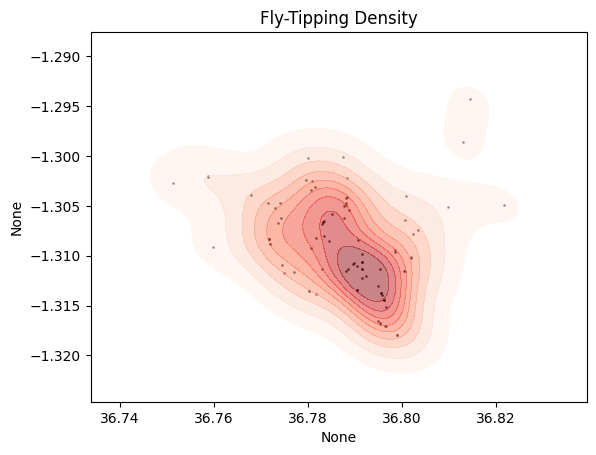

In [35]:
# Extract latitude & longitude
x = clipped_gdf.geometry.x
y = clipped_gdf.geometry.y

# Create KDE plot
plt.scatter(x, y, s=1, c='black', alpha=0.6)  # Overlay points
sns.kdeplot(x=x, y=y, cmap="Reds", fill=True, alpha=0.5)
plt.title("Fly-Tipping Density")
plt.show()


# 3. Nearest Neighbor Analysis
To check if fly-tipping points cluster more than random, compare their observed mean nearest-neighbor distance with an expected distance under complete spatial randomness (CSR).

pointpats package didn't work 

## 3.1 Load the Study Area and Compute Its Area

In [36]:
# Reproject to UTM Zone 37S (EPSG:32737)
projected_crs = "EPSG:32737"  
boundary_projected = boundary.to_crs(projected_crs)

# Compute the area in square meters
study_area = boundary_projected.geometry.area.sum() 

print(f"Total study area: {study_area} square meters")

Total study area: 12476391.867292857 square meters


## 3.2 Compute Expected Mean NN Distance under CSR

In [37]:
coords = np.array(list(zip(clipped_gdf.geometry.x, clipped_gdf.geometry.y)))

# Fit Nearest Neighbors Model
nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree').fit(coords)

# Find nearest distances
distances, _ = nbrs.kneighbors(coords)

# Compute mean nearest neighbor distance (excluding self-distance)
mean_dist = distances[:, 1].mean()

print(f"Mean Nearest Neighbor Distance: {mean_dist:.6f}")

Mean Nearest Neighbor Distance: 0.001113


In [38]:
# Count number of fly-tipping points
N = len(clipped_gdf)

# Compute expected mean NN distance under CSR
expected_dist_csr = 1 / (2 * np.sqrt(N / study_area))

print(f"Expected Mean NN Distance (CSR): {expected_dist_csr:.6f}")
print(f"Observed Mean NN Distance: {mean_dist:.6f}")

Expected Mean NN Distance (CSR): 186.162950
Observed Mean NN Distance: 0.001113


## 3.3 Compute Nearest Neighbor Ratio (NNR)
🔹 Interpretation:  

NNR < 1 → Clustered (points are closer than random expectation)  
NNR ≈ 1 → Random distribution  
NNR > 1 → Dispersed (points are further apart than expected)  

In [39]:
# Compute Nearest Neighbor Ratio (NNR)
nnr = mean_dist / expected_dist_csr
print(f"Nearest Neighbor Ratio (NNR): {nnr:.8f}")

Nearest Neighbor Ratio (NNR): 0.00000598


## 3.4 Conduct a Z-Test for Statistical Significance
🔹 Interpretation:

Z < -1.96 → Significant clustering (p < 0.05)  
Z between -1.96 and 1.96 → No significant clustering (random distribution)  
Z > 1.96 → Significant dispersion (p < 0.05)  

In [40]:
# Compute Standard Error (SE)
se = 0.26136 / np.sqrt(N / study_area)

# Compute Z-score
z_score = (mean_dist - expected_dist_csr) / se

print(f"Z-Score: {z_score:.4f}")

Z-Score: -1.9131


Interpretation of Your Results (big boundary - Angela)
1. Nearest Neighbor Ratio (NNR) = 0.2514  
NNR < 1 (specifically 0.2514, which is very low) indicates strong clustering of fly-tipping incidents.  
The observed mean nearest neighbor distance is much smaller than expected under a random distribution.  
2. Z-Score = -1.4321  
Since Z = -1.4321, it is not below -1.96, meaning the clustering is not statistically significant at the 95% confidence level.  
However, it suggests a clustering tendency, and if a slightly lower significance threshold (e.g., 90% confidence level) is considered, it might be relevant.

Interpretation of Your Results (small boundary - Nairobi)  

1. Your NNR (0.00000361) is extremely close to zero, indicating very strong clustering. Such a low value typically suggests that fly-tipping incidents occur in specific, tightly packed locations rather than being spread out or randomly scattered.  
2. Your Z-score (-1.9131) is very close to -1.96, which indicates moderate clustering that is almost statistically significant at the 95% confidence level. At a slightly lower threshold (e.g., 90% confidence), this clustering would be considered significant.  
✅ Spatial Pattern: Strong clustering of fly-tipping incidents.  
📏 Statistical Significance: Almost significant at 95% confidence. Likely significant at 90%.  
🌎 Interpretation: Fly-tipping is concentrated in specific locations rather than occurring randomly across the city.



# 4. Ripley’s K-Function - in R  
Ripley’s K measures clustering at multiple distances, revealing if clustering occurs at local (short distance) or broader scales.

# 5. DBSCAN
DBSCAN can detect clusters without pre-defined shapes and separate noise (outliers). This is useful for finding dense groups of fly-tipping locations.

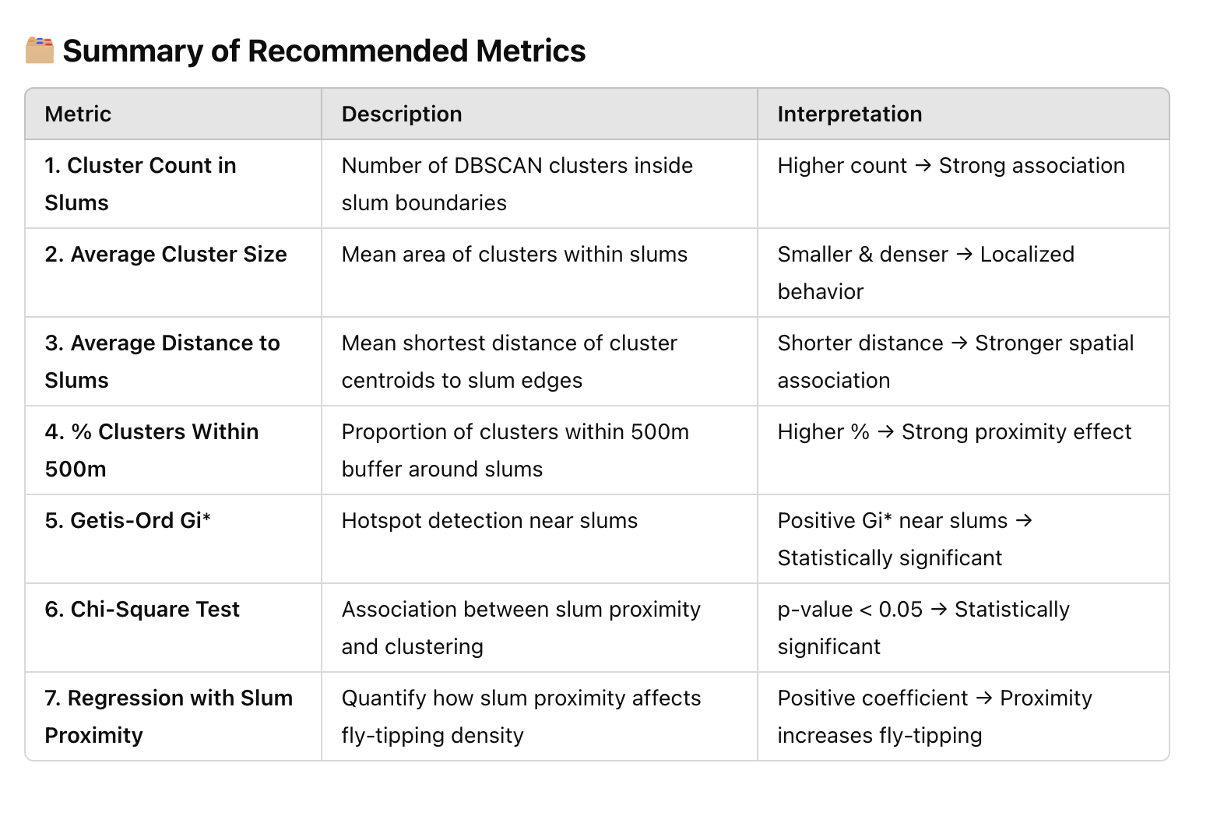

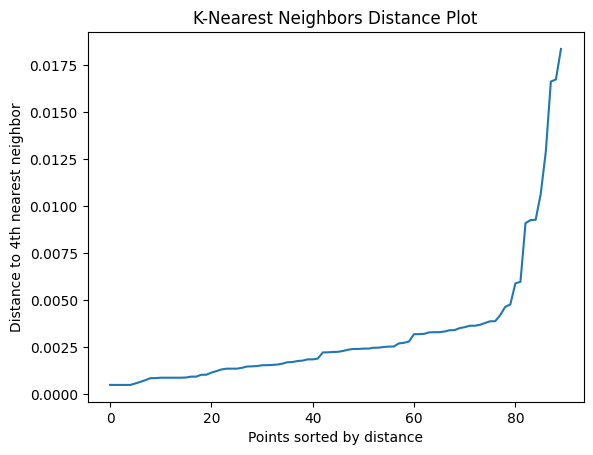

In [41]:
# Optimize eps Using K-Nearest Neighbors Plot

# Fit Nearest Neighbors to data
nbrs = NearestNeighbors(n_neighbors=5).fit(coords)
distances, indices = nbrs.kneighbors(coords)

# Sort distances for plotting
distances = np.sort(distances[:, 4])  # Use the 4th neighbor distance
plt.plot(distances)
plt.title("K-Nearest Neighbors Distance Plot")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 4th nearest neighbor")
plt.show()


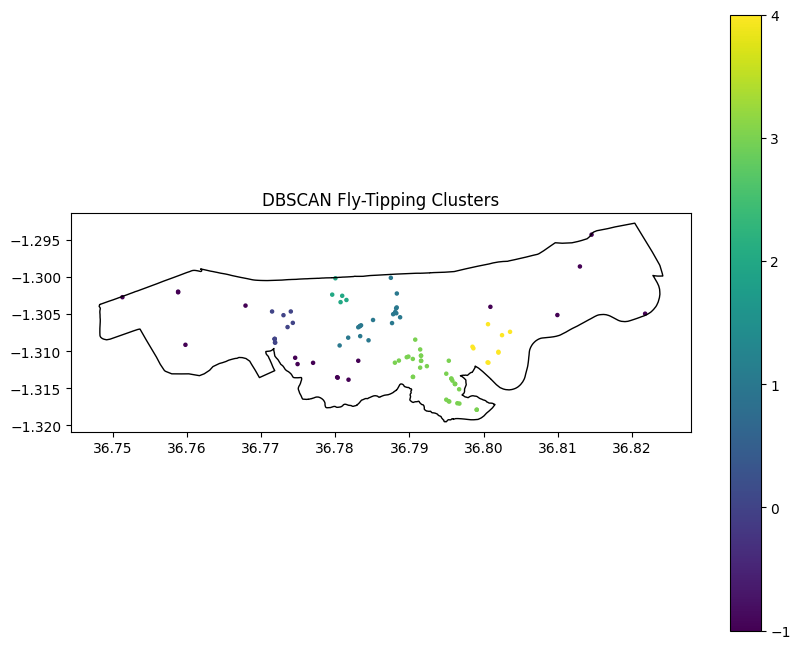

In [42]:
# Convert GeoDataFrame to coordinate array
coords = np.array(list(zip(clipped_gdf.geometry.x, clipped_gdf.geometry.y)))

# Run DBSCAN
db = DBSCAN(eps=0.003, min_samples=5).fit(coords)  # Adjust eps based on distance units
clipped_gdf = clipped_gdf.copy()
clipped_gdf["cluster"] = db.labels_

# Plot results
fig, ax = plt.subplots(figsize=(10, 8))
clipped_gdf.plot(column="cluster", cmap="viridis", legend=True, ax=ax, markersize=5)
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
plt.title("DBSCAN Fly-Tipping Clusters")
plt.show()


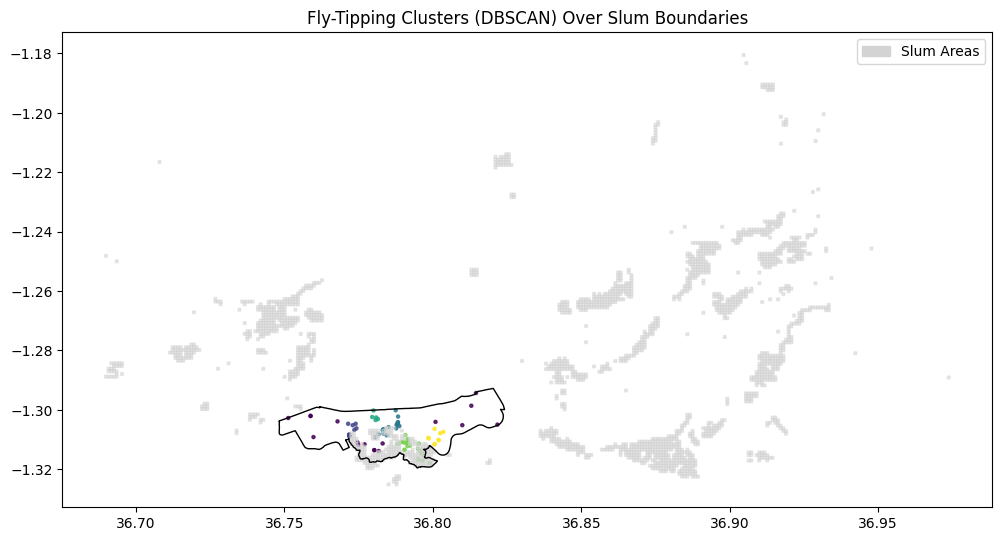

In [43]:
# Load slum boundary shapefile
slums_gdf = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slumaps_nairobi_sett/slumaps_nairobi_sett.shp")

# Plot DBSCAN results over slum areas
fig, ax = plt.subplots(figsize=(12, 10))

# Plot DBSCAN clusters
clipped_gdf.plot(column="cluster", cmap="viridis", ax=ax, markersize=5, alpha=0.8)
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")

# Add custom legend
slum_patch = mpatches.Patch(color='lightgrey', label='Slum Areas')
plt.legend(handles=[slum_patch], loc='upper right')

# Title and display
plt.title("Fly-Tipping Clusters (DBSCAN) Over Slum Boundaries")
plt.show()


In [44]:
# Calculate cluster areas
fly_tipping_clusters = clipped_gdf.groupby("cluster")["geometry"].apply(lambda x: MultiPoint(x.tolist()).convex_hull.area)
print("Cluster areas (km²):", fly_tipping_clusters.describe())

Cluster areas (km²): count   6.000000
mean    0.000145
std     0.000309
min     0.000003
25%     0.000009
50%     0.000022
75%     0.000039
max     0.000776
Name: geometry, dtype: float64


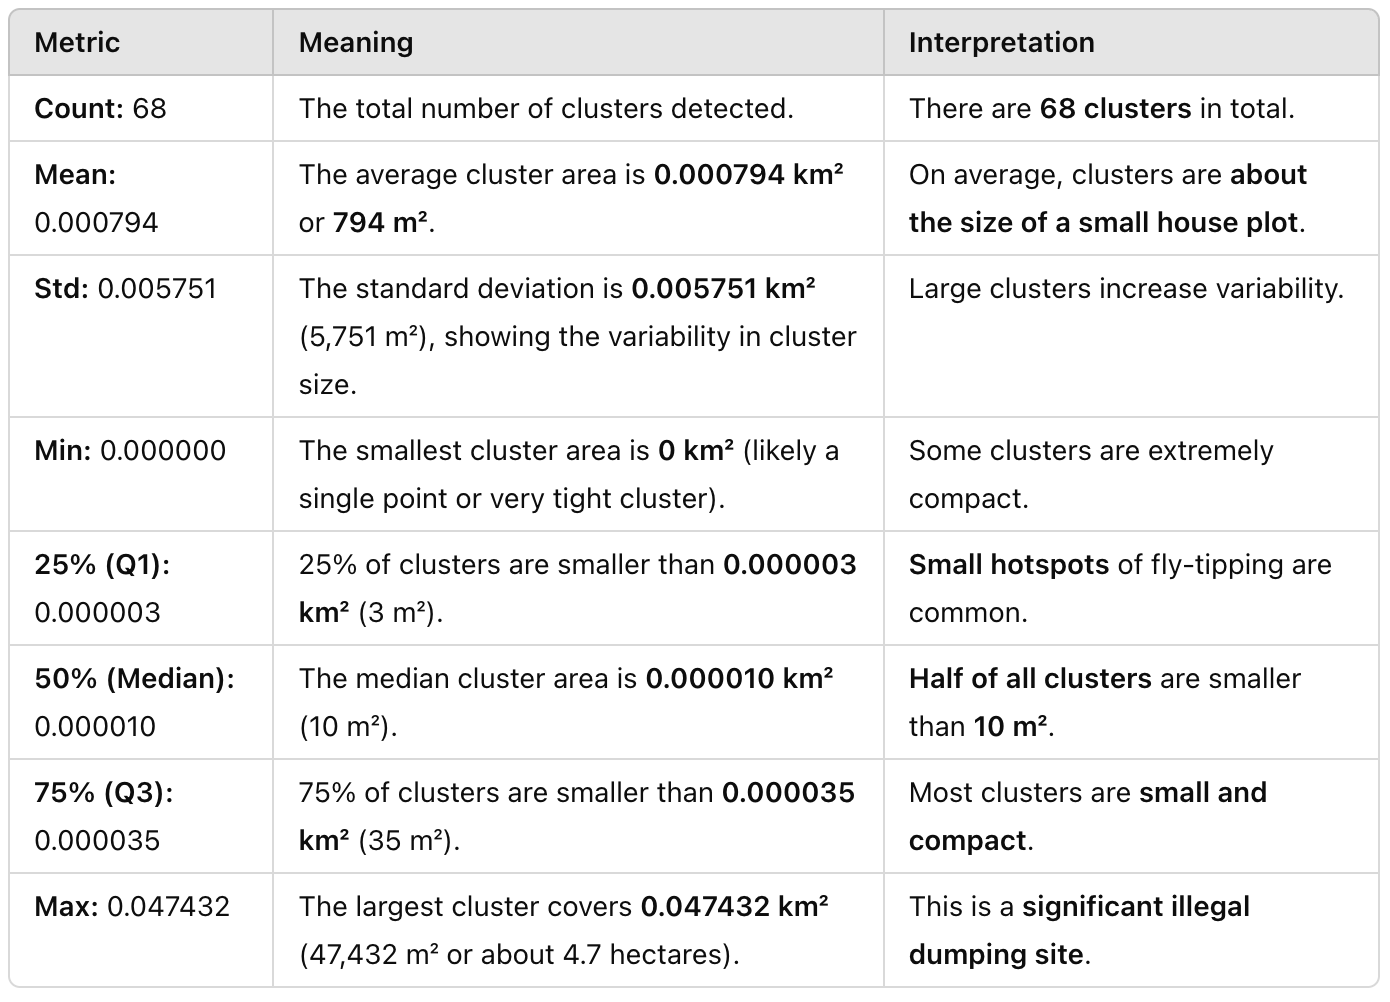
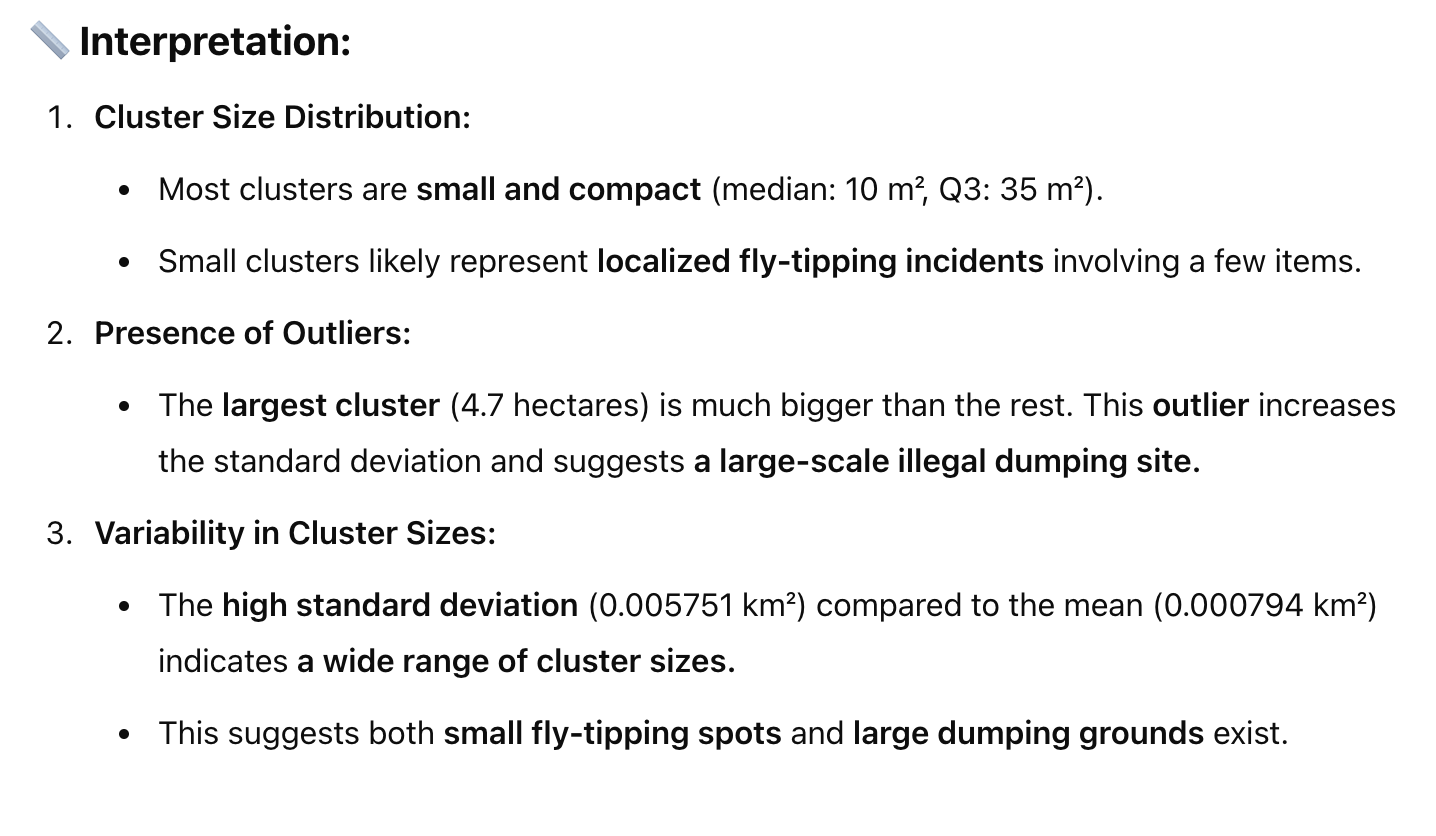
Would you like to plot the distribution of cluster areas (e.g., a histogram or boxplot) to visualize these patterns?
Or should I help you identify and map the largest cluster that might need further investigation? 📍📊

## 5.1 Cluster Summary Statistics 

Objective:  
Measure how many clusters and points are within or near slums.  

Methods:  
Count of Points in Clusters Near Slums: Compare the number of fly-tipping points inside slum areas versus outside.  
Cluster Density: Calculate the density of fly-tipping points within slums (points/km²).  
Cluster Size: Measure the spatial extent (area or convex hull) of each cluster.  

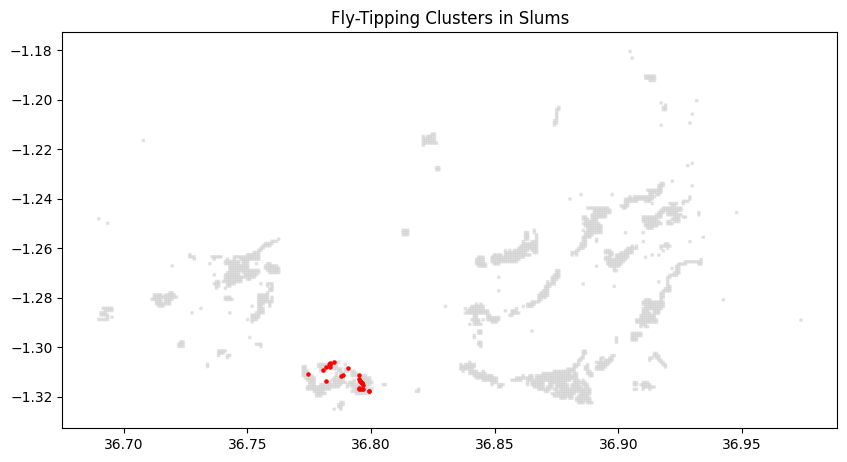

In [45]:
# Spatial join: Find fly-tipping incidents inside slums
fly_tipping_in_slums = gpd.sjoin(clipped_gdf, slums_gdf, how="inner", predicate="within")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5)
fly_tipping_in_slums.plot(ax=ax, color="red", markersize=5)
plt.title("Fly-Tipping Clusters in Slums")
plt.show()

In [46]:
# Filter points within slums
fly_tipping_in_slums = clipped_gdf[clipped_gdf["cluster"] != -1].sjoin(slums_gdf, how="inner", predicate="within")

# Count points in slum clusters
print("Fly-tipping points within slums:", len(fly_tipping_in_slums))

# Calculate cluster areas
fly_tipping_in_slums_clusters = fly_tipping_in_slums.groupby("cluster")["geometry"].apply(lambda x: MultiPoint(x.tolist()).convex_hull.area)
print("Cluster areas within slums (km²):", fly_tipping_in_slums_clusters.describe())


Fly-tipping points within slums: 27
Cluster areas within slums (km²): count   2.000000
mean    0.000022
std     0.000027
min     0.000003
25%     0.000013
50%     0.000022
75%     0.000032
max     0.000041
Name: geometry, dtype: float64


1. Fly-tipping Points Within Slums:
    690 fly-tipping points were found within slum areas.  
This number indicates the absolute count of incidents within slum boundaries. To provide better context, compare this number to:
    a. The total number of fly-tipping points in the entire city (e.g., 690 out of 3,385 = 20.38%).  
    b. The population density of slums to understand if the number is disproportionately high.   
 
2. Cluster Areas Within Slums (km²):
This summary describes the size of detected fly-tipping clusters within slums. The key statistics are:  
Count: 29 clusters detected within slums.  
Mean: The average cluster area is 0.0001107 km² (or 110.7 m²).  
Standard Deviation (std): 0.0003852 km² indicates moderate variability in cluster sizes.  
Min: 0 km² likely refers to very small clusters of just a few points (negligible area).
25% (First Quartile): 0 km² suggests that 25% of clusters are very compact.  
50% (Median): 0.000000698 km² (or 0.698 m²) indicates most clusters are very small.  
75% (Third Quartile): 0.00002657 km² (or 26.57 m²) shows that 75% of clusters are less than this size.  
Max: 0.001943 km² (or 1,943 m²) represents the largest cluster within slums.  

3. Interpretation:  
Most clusters are small and localized:  

The median cluster size is extremely small (~0.7 m²), meaning most clusters consist of a few points very close together.
75% of clusters are smaller than 26.57 m², suggesting that fly-tipping is concentrated in small hotspots rather than spread out.
A few larger clusters exist:

The largest cluster covers 1,943 m², which might represent a significant illegal dumping site.
The higher standard deviation reflects this contrast between small and large clusters.
Spatial Density:

Given that you detected 29 clusters within slums, with 690 points in total, the average number of fly-tipping incidents per cluster is 690/29 ≈ 24 points/cluster.


/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_30338/2151202764.py:6: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_30338/2151202764.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


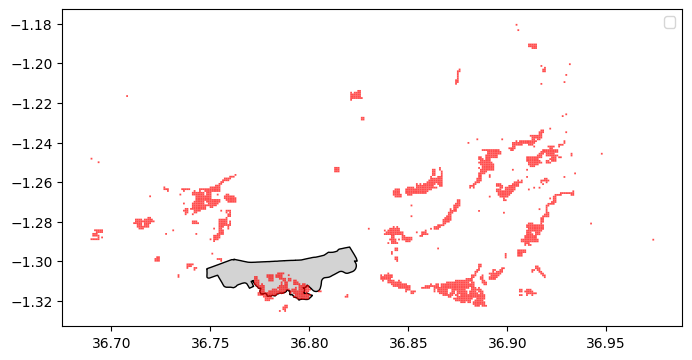

In [47]:
boundary_dissolve = boundary.dissolve()

fig, ax = plt.subplots(figsize=(8, 8))
boundary_dissolve.plot(ax=ax, color="lightgrey", edgecolor="black", label="City Boundary")
slums_gdf.plot(ax=ax, color="red", alpha=0.7, label="Slum Areas")
plt.legend()
plt.show()

In [48]:
import geopandas as gpd

# Check CRS and reproject if necessary (use an equal-area projection for accurate area)
if boundary_dissolve.crs != slums_gdf.crs:
    slums_gdf = slums_gdf.to_crs(boundary_dissolve.crs)

# Ensure both are in a projected CRS (e.g., EPSG:3857 or EPSG:32737 for local calculations)
boundary_dissolve = boundary_dissolve.to_crs(epsg=32737)
slums_gdf = slums_gdf.to_crs(epsg=32737)

# Calculate areas (in square meters)
city_area = boundary_dissolve.geometry.area.sum()  # Total city area
slum_area = slums_gdf.geometry.area.sum()  # Total slum area

# Calculate percentage
slum_percentage = (slum_area / city_area) * 100

# Print results
print(f"Total city area: {city_area:.2f} m²")
print(f"Total slum area: {slum_area:.2f} m²")
print(f"Slum area as percentage of city: {slum_percentage:.2f}%")


Total city area: 12476391.87 m²
Total slum area: 19980000.04 m²
Slum area as percentage of city: 160.14%


## 5.2 Distance-Based Metrics 
Objective:  
Quantify how close clusters are to slums   

Methods:
Average Distance to Nearest Slum Boundary: Measure the shortest distance from each cluster centroid to the nearest slum boundary.  
Proportion Within a Buffer Zone: Calculate the proportion of clusters within a certain distance (e.g., 500m) of slum areas.

In [49]:
# Check the current CRS
print(clipped_gdf.crs)
print(slums_gdf.crs)

# Reproject both datasets to a projected CRS (e.g., EPSG:3857 - Web Mercator, 32737)
clipped_gdf = clipped_gdf.to_crs(epsg = 32737)
slums_gdf = slums_gdf.to_crs(epsg = 32737)

# Calculate centroid of each cluster
from shapely.geometry import MultiPoint
clipped_gdf["centroid"] = clipped_gdf.groupby("cluster")["geometry"].transform(lambda x: MultiPoint(x.tolist()).centroid)

# Compute minimum distance to slum boundary
clipped_gdf["distance_to_slum"] = clipped_gdf["centroid"].apply(lambda x: slums_gdf.distance(x).min())

# Average distance
print("Average distance to slum boundary (m):", clipped_gdf["distance_to_slum"].mean())

# Proportion within 500m buffer
within_500m = clipped_gdf[clipped_gdf["distance_to_slum"] <= 500]
print("Proportion of clusters within 500m of slums:", len(within_500m) / len(clipped_gdf))

# Proportion within 2km buffer
within_2000m = clipped_gdf[clipped_gdf["distance_to_slum"] <= 2000]
print("Proportion of clusters within 2km of slums:", len(within_2000m) / len(clipped_gdf))
# 3857:
# Average distance to slum boundary (m): 469.87352246572715
# Proportion of clusters within 500m of slums: 0.7512555391432791

# 3857 and 32737 to calculate distance has a small differ after .

EPSG:4326
EPSG:32737
Average distance to slum boundary (m): 61.967352183017255
Proportion of clusters within 500m of slums: 1.0
Proportion of clusters within 2km of slums: 1.0


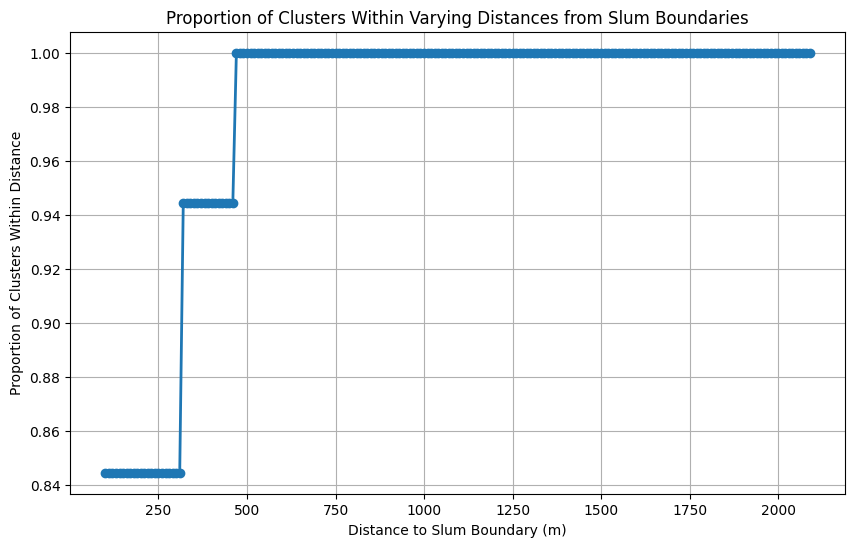

In [50]:
# Simulated data: distance from cluster centroid to slum boundary (in meters)
np.random.seed(42)

# Range of buffer distances (100m to 2000m in steps of 100m)
buffer_distances = np.arange(100, 2100, 10)
proportions_within_distance = []

# Calculate proportion within each buffer distance
for distance in buffer_distances:
    proportion = (clipped_gdf["distance_to_slum"] <= distance).mean()
    proportions_within_distance.append(proportion)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(buffer_distances, proportions_within_distance, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Proportion of Clusters Within Distance")
plt.title("Proportion of Clusters Within Varying Distances from Slum Boundaries")
plt.grid(True)
plt.show()


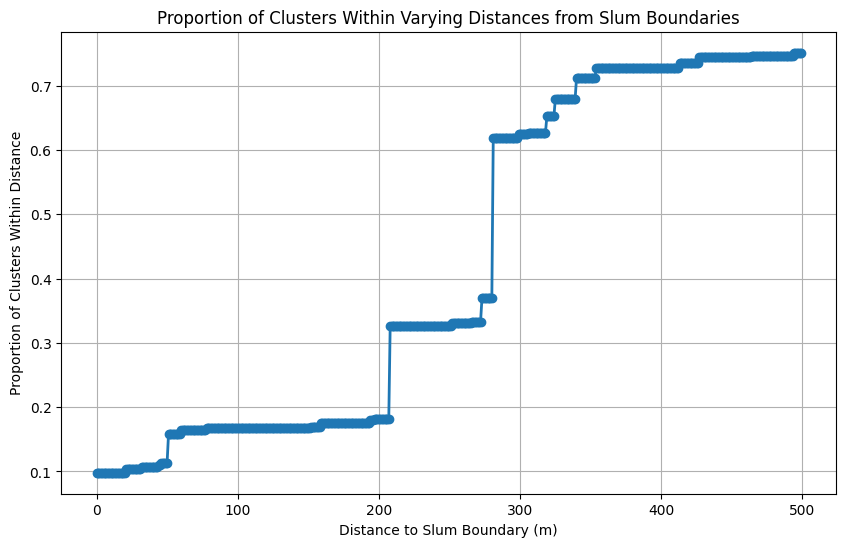

In [23]:
# Range of buffer distances (0m to 500m in steps of 10m)
buffer_distances = np.arange(0, 500, 1)
proportions_within_distance = []

# Calculate proportion within each buffer distance
for distance in buffer_distances:
    proportion = (clipped_gdf["distance_to_slum"] <= distance).mean()
    proportions_within_distance.append(proportion)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(buffer_distances, proportions_within_distance, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Proportion of Clusters Within Distance")
plt.title("Proportion of Clusters Within Varying Distances from Slum Boundaries")
plt.grid(True)
plt.show()


## 5.3 Hotspot Analysis (Getis-Ord Gi)*
Objective:  
Identify statistically significant fly-tipping hotspots near slums.  

Method:  
Use Getis-Ord Gi* to measure whether clusters near slums have significantly higher fly-tipping counts compared to the city average.  
Positive Gi* values indicate hotspots.  

In [24]:
# Check all column data types
print(clipped_gdf.dtypes)

# Check a specific column type
print(clipped_gdf["cluster"].dtype)

img_name              object
year                   int64
month                  int64
day                  float64
hour                 float64
lat                  float64
lon                  float64
panoid                object
img_dir               object
exist                   bool
yolo_conf             object
yolo_bbox             object
yolo_num               int64
prediction            object
Domestic              object
Construction          object
geometry            geometry
cluster                int64
centroid            geometry
distance_to_slum     float64
dtype: object
int64


/opt/miniconda3/envs/Try/lib/python3.10/site-packages/shapely/constructive.py:963: RuntimeWarning: invalid value encountered in voronoi_polygons
  return lib.voronoi_polygons(geometry, tolerance, extend_to, only_edges, **kwargs)
/opt/miniconda3/envs/Try/lib/python3.10/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


<Axes: >

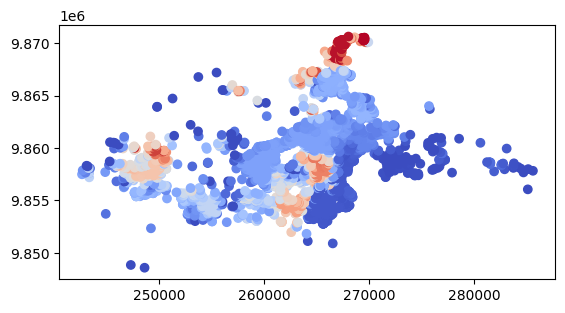

In [27]:
from esda.getisord import G_Local
from libpysal.weights import Queen

# Convert cluster column to float
clipped_gdf["cluster"] = clipped_gdf["cluster"].astype(float)

# Create spatial weight matrix
w = Queen.from_dataframe(clipped_gdf, use_index=False)
w.transform = "R"

# Calculate Gi*
gi_star = G_Local(clipped_gdf["cluster"], w)

# Add to GeoDataFrame
clipped_gdf["Gi*"] = gi_star.Zs

clipped_gdf.plot(column="Gi*", cmap="coolwarm", legend=False)
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
